# Tarea 2 P1

**Estudiante:** Antonia Migliassi 

**Profesores:** Ariel Norambuena; Nicolás Viaux 

**Ayudante:** Cristóbal Benavides

**Ramo:** FIS205

**Fecha:** 22 de junio de 2026

## **Problema 1:** Inteligencia artificial para problemas inversos


### a) 

#### **· Problema Inverso:**

Como se menciona en el problema directo se conoce el modelo, las leyes de la física (EDO) y los parámetros del sistema ($\gamma , k$). Por consecuencia $x(t)$ es una solución única y conociendo si es bien portada. Sin embargo, en el problema inverso las principales dificultades son:

* **Falta de unicidad:** Debido al ruido experimental podemos llegar a que distintas combinaciones de parámetros pueden generar señales que se vean idénticas a simple vista.

* **Sensibilidad:** Pequeñas fluctuaciones en los datos pueden hacer que un algoritmo optimizado capte valores de parámetros que son completamente erróneos y no habría forma de saber si sin parámetros erróneos.

* **Costo computacional:** Resolverlo sin los parámetros implicaría ajustar pudiendo ser con mínimos cuadrados o dependiendo del problema, lo complejo es que este proceso sería por cada curva lo cual puede implicar en algunas ocasiones un gran costo computacional en hallar la curva.

#### **· Aprendizaje supervisado:**

Absolutamente y completamente necesario, ya que si estamos bajo el algoritmo de Aprendizaje supervisado el modelo necesita de unas etiquetas para posteriormente correguir sus errores mediante funciones de pérdida. Si no se pasan las etiquetas el algoritmo de regresión no tiene con que comparar la predicción por lo que no puede actualizar sus pesos o árboles de decisión

#### **· Conjuntos de entrenamiento y validación:**

Se separan para evitar el $Overfitting$ (Sobreajuste), es decir si se entrena un modelo exclusivamente con el grupo $Train$ este solo reconocerá patrones. Pero llegados a unos datos de tipo $Test$, le servirá al modelo mantener una generalización. Por eso es tan importante en los modelos tener unos datos tipo $Test$ y $Train$, uno para que el modelo aprenda y el otro para poner a prueba.

#### **· Función de pérdida:**

Es importante ya que nos permite saber que tan mala es la predicción del modelo en comparación con la respuesta real. Y en redes neuronales es importante ya que gracias a esto se realiza una corrección en el error para justar las ecuaciones internas.

### b) 


![Gráfico inciso b](imagenes/grafico%20inciso%20b.jpeg)

Se puede observar en el gráfico que para $k$ bajo la señal tiende a ser ancha, pero para $k$ altos se acorta así cumpliendo más ciclos para un mismo periodo.

Por otra parte si vemos el decaimiento influye directamente en que tan rápido converge a cero. Viendo por ejemplo el $\gamma = 0.85$ se amortigua más rápido que $\gamma= 0.52$.

Iniciando la simulación de 3000 señales...
¡Simulación completada con éxito!


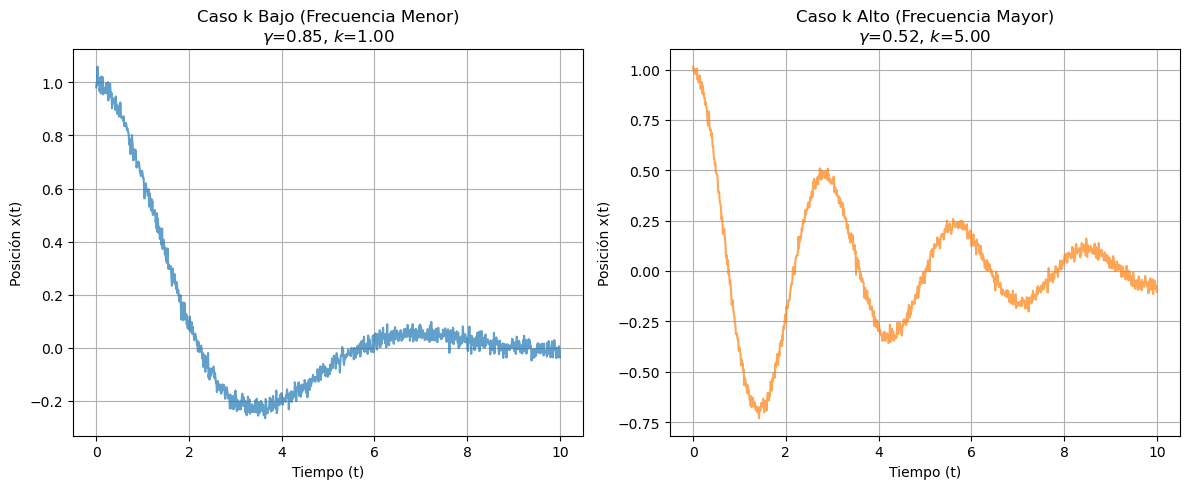

Datos de entrenamiento: 2400 señales.
Datos de validación (test): 600 señales.

Entrenando RandomForestRegressor (esto puede tomar unos segundos)...


KeyboardInterrupt: 

In [6]:
# --- Inciso b ---

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. Definición del sistema de EDOs (m = 1)
def oscilador_amortiguado(t, y, gamma, k):
    x, v = y
    dxdt = v
    dvdt = -gamma * v - k * x
    return [dxdt, dvdt]

# 2. Configuración de parámetros y generación de datos
N_signals = 3000
N_t = 1000
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], N_t)
y0 = [1.0, 0.0]  # x(0)=1, v(0)=0
sigma = 0.02

# Semilla aleatoria para que los resultados sean reproducibles
np.random.seed(42)

# Generar distribuciones uniformes para los parámetros
gammas = np.random.uniform(0.05, 1.0, size=N_signals)
ks = np.random.uniform(1.0, 5.0, size=N_signals)

# Preasignación de matrices de datos
X_data = np.zeros((N_signals, N_t))
Y_data = np.zeros((N_signals, 2))

print("Iniciando la simulación de 3000 señales...")
for i in range(N_signals):
    gamma_i = gammas[i]
    k_i = ks[i]
    
    # Resolver la EDO analíticamente/numéricamente en los 1000 puntos
    sol = solve_ivp(oscilador_amortiguado, t_span, y0, args=(gamma_i, k_i), t_eval=t_eval)
    x_clean = sol.y[0]
    
    # Agregar ruido gaussiano independiente
    ruido = np.random.normal(0, sigma, size=N_t)
    x_noisy = x_clean + ruido
    
    # Guardar en las matrices correspondientes
    X_data[i, :] = x_noisy
    Y_data[i, :] = [gamma_i, k_i]

print("¡Simulación completada con éxito!")

# --- Bloque de Gráficos ---
# Buscamos dos casos extremos para comparar
idx_baja_osc = np.argmin(ks)   # El k más bajo 
idx_alta_osc = np.argmax(ks)   # El k más alto 

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_eval, X_data[idx_baja_osc, :], color='tab:blue', alpha=0.7)
plt.title(f"Caso k Bajo (Frecuencia Menor)\n$\gamma$={gammas[idx_baja_osc]:.2f}, $k$={ks[idx_baja_osc]:.2f}")
plt.xlabel("Tiempo (t)")
plt.ylabel("Posición x(t)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_eval, X_data[idx_alta_osc, :], color='tab:orange', alpha=0.7)
plt.title(f"Caso k Alto (Frecuencia Mayor)\n$\gamma$={gammas[idx_alta_osc]:.2f}, $k$={ks[idx_alta_osc]:.2f}")
plt.xlabel("Tiempo (t)")
plt.ylabel("Posición x(t)")
plt.grid(True)

plt.tight_layout()
plt.show()


# --- Inciso c ---

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# 1. Separación de datos: 80% entrenamiento y 20% validación
# X_data: (3000, 1000) -> señales con ruido
# Y_data: (3000, 2)    -> columnas de [gamma, k]
X_train, X_test, Y_train, Y_test = train_test_split(
    X_data, Y_data, test_size=0.20, random_state=42
)

# Extraemos los valores reales del conjunto de testeo para evaluar al final
gamma_test_real = Y_test[:, 0]
k_test_real = Y_test[:, 1]

print(f"Datos de entrenamiento: {X_train.shape[0]} señales.")
print(f"Datos de validación (test): {X_test.shape[0]} señales.\n")

# =====================================================================
# MODELO 1: Random Forest Regressor
# =====================================================================
print("Entrenando RandomForestRegressor (esto puede tomar unos segundos)...")
# Usamos n_jobs=-1 para aprovechar todos los núcleos de tu procesador
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, Y_train)

# Predicciones
preds_rf = rf_model.predict(X_test)
gamma_preds_rf = preds_rf[:, 0]
k_preds_rf = preds_rf[:, 1]

# Cálculo de RMSE para Random Forest
rmse_gamma_rf = np.sqrt(mean_squared_error(gamma_test_real, gamma_preds_rf))
rmse_k_rf = np.sqrt(mean_squared_error(k_test_real, k_preds_rf))


# =====================================================================
# MODELO 2: MLP Regressor (Red Neuronal)
# =====================================================================
print("Entrenando MLPRegressor...")
# Definimos una red con dos capas ocultas (100 neuronas en la primera, 50 en la segunda)
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp_model.fit(X_train, Y_train)

# Predicciones
preds_mlp = mlp_model.predict(X_test)
gamma_preds_mlp = preds_mlp[:, 0]
k_preds_mlp = preds_mlp[:, 1]

# Cálculo de RMSE para la Red Neuronal
rmse_gamma_mlp = np.sqrt(mean_squared_error(gamma_test_real, gamma_preds_mlp))
rmse_k_mlp = np.sqrt(mean_squared_error(k_test_real, k_preds_mlp))


# =====================================================================
# REPORTAR RESULTADOS
# =====================================================================
print("\n" + "="*40)
print("REPORTE DE DESEMPEÑO (RMSE)")
print("="*40)
print(f" Random Forest:")
print(f"   - RMSE en Gamma (Amortiguamiento): {rmse_gamma_rf:.4f}")
print(f"   - RMSE en K (Constante elástica):  {rmse_k_rf:.4f}")
print("-"*40)
print(f"MLP Regressor (Red Neuronal):")
print(f"   - RMSE en Gamma (Amortiguamiento): {rmse_gamma_mlp:.4f}")
print(f"   - RMSE en K (Constante elástica):  {rmse_k_mlp:.4f}")
print("="*40)

### c)

Tenemos que el desempeño para Random Forest fueron los siguientes.

* **RMSE en Gamma (Amortiguamiento):** 0.0160
* **RMSE en K (Constante elástica):** 0.1711

Por otro lado para MLP Regressor (Red Neuronal):

* **RMSE en Gamma (Amortiguamiento):** 0.0289
* **RMSE en K (Constante elástica):** 0.0433

Con estos datos, podemos evidenciar que el Random Forest fue altamente preciso con el amortiguamiento, contrariamente el MLP. Sin embargo al predecir la constante elástica el error en Random Forest se dispara y MLP Regressor resulta tener un rendimiento más balanceado y robusto.

Podemos evidenciar que dependiendo de la naturaleza que poseen para abarcar el problema fue significativo al momento de predecir cálculos, ya que RF al ser un algoritmo basado en árboles le dificultó aproximar la constante elástica, contrario a la Red Neuronal que posee una naturaleza similar a filtros de frecuencias.

### d)

![grafico inciso c](imagenes/grafico%20inciso%20c.png)

Si observamos los gráficos, podemos contemplar que el parámetro más difícil de inferir es la constante elástica $k$. Esto se debe a la sensibilidad que posee, sabemos que $\omega_0=\sqrt{\frac{k}{m}}$ donde un cambio sutil en $k$ altera el ritmo de las oscilaciones, esto perjudica directamente a métodos como Random Forest ya que evalúa valores de posición en tiempos fijos donde un desfase hace que los valores fluctúen drásticamente.

El $overfitting$ se manifieta como una pérdida en la capcidad de generalización. Por ejemplo en este caso el modelo durante el entrenamiento si el ruido $\sigma$ es grande, en lugar de aprender la EDO, el modelo solo memoriza las fluctuaciones aleatorias específicas.

Generando base de señales teóricas limpias...

Iniciando el experimento con diferentes niveles de ruido...
-> Procesando sigma = 0
-> Procesando sigma = 0.01
-> Procesando sigma = 0.02
-> Procesando sigma = 0.05
-> Procesando sigma = 0.1


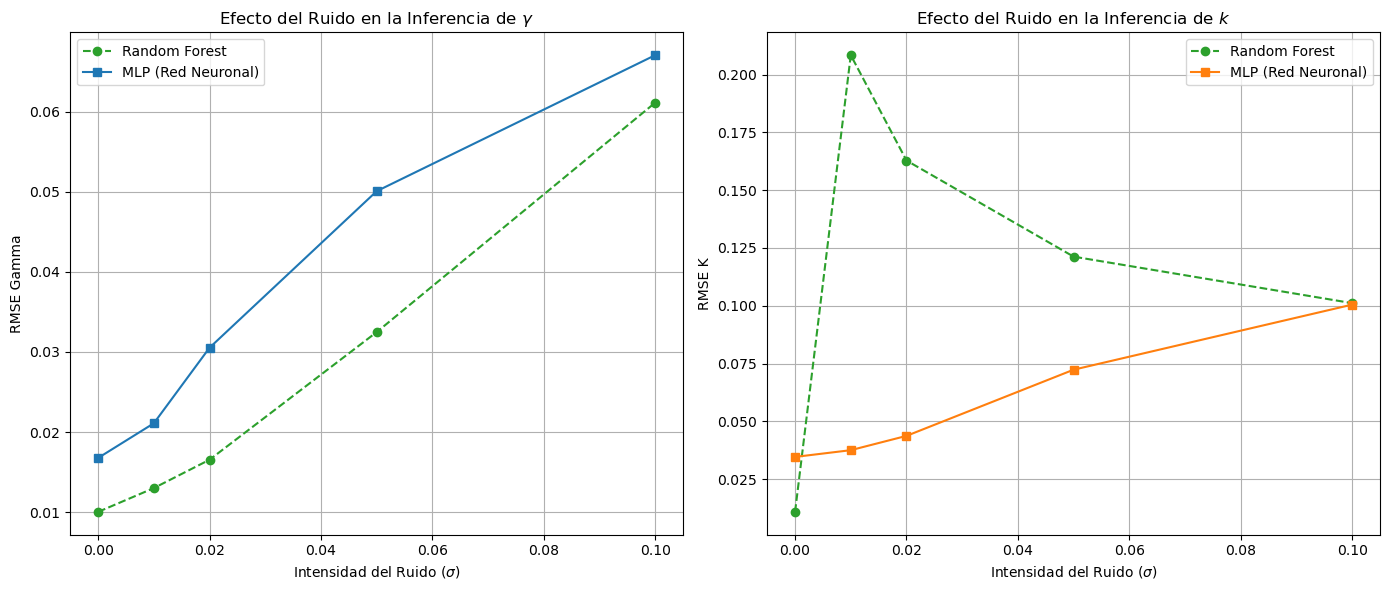

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from scipy.integrate import solve_ivp

# --- Configuración Base ---
N_signals = 3000
N_t = 1000
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], N_t)
y0 = [1.0, 0.0]

def oscilador_amortiguado(t, y, gamma, k):
    x, v = y
    return [v, -gamma * v - k * x]

# Generar parámetros teóricos base fixed
np.random.seed(42)
gammas = np.random.uniform(0.05, 1.0, size=N_signals)
ks = np.random.uniform(1.0, 5.0, size=N_signals)

# 1. Primero generamos y guardamos las 3000 SEÑALES LIMPIAS (sin ruido)
X_clean_all = np.zeros((N_signals, N_t))
Y_data = np.zeros((N_signals, 2))

print("Generando base de señales teóricas limpias...")
for i in range(N_signals):
    sol = solve_ivp(oscilador_amortiguado, t_span, y0, args=(gammas[i], ks[i]), t_eval=t_eval)
    X_clean_all[i, :] = sol.y[0]
    Y_data[i, :] = [gammas[i], ks[i]]

# --- Barrido de Ruido Experimental ---
sigmas = [0, 0.01, 0.02, 0.05, 0.10]

# Listas para almacenar los resultados y poder graficar
rf_rmse_gamma, rf_rmse_k = [], []
mlp_rmse_gamma, mlp_rmse_k = [], []

print("\nIniciando el experimento con diferentes niveles de ruido...")
for sigma in sigmas:
    print(f"-> Procesando sigma = {sigma}")
    
    # Agregar el nivel de ruido correspondiente a las señales limpias
    if sigma > 0:
        ruido = np.random.normal(0, sigma, size=(N_signals, N_t))
        X_noisy = X_clean_all + ruido
    else:
        X_noisy = X_clean_all.copy() # Caso ideal sin ruido
        
    # Separar en 80% train y 20% test
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_noisy, Y_data, test_size=0.20, random_state=42
    )
    gamma_test_real = Y_test[:, 0]
    k_test_real = Y_test[:, 1]
    
    # --- Entrenar y Evaluar Random Forest ---
    rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1) # 50 árboles para acelerar el bucle
    rf.fit(X_train, Y_train)
    preds_rf = rf.predict(X_test)
    rf_rmse_gamma.append(np.sqrt(mean_squared_error(gamma_test_real, preds_rf[:, 0])))
    rf_rmse_k.append(np.sqrt(mean_squared_error(k_test_real, preds_rf[:, 1])))
    
    # --- Entrenar y Evaluar MLP (Red Neuronal) ---
    mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)
    mlp.fit(X_train, Y_train)
    preds_mlp = mlp.predict(X_test)
    mlp_rmse_gamma.append(np.sqrt(mean_squared_error(gamma_test_real, preds_mlp[:, 0])))
    mlp_rmse_k.append(np.sqrt(mean_squared_error(k_test_real, preds_mlp[:, 1])))

# --- Generación de Gráficos de Rendimiento ---
plt.figure(figsize=(14, 6))

# Gráfico para Gamma
plt.subplot(1, 2, 1)
plt.plot(sigmas, rf_rmse_gamma, 'o--', label='Random Forest', color='tab:green')
plt.plot(sigmas, mlp_rmse_gamma, 's-', label='MLP (Red Neuronal)', color='tab:blue')
plt.title(r'Efecto del Ruido en la Inferencia de $\gamma$')
plt.xlabel(r'Intensidad del Ruido ($\sigma$)')
plt.ylabel('RMSE Gamma')
plt.grid(True)
plt.legend()

# Gráfico para K
plt.subplot(1, 2, 2)
plt.plot(sigmas, rf_rmse_k, 'o--', label='Random Forest', color='tab:green')
plt.plot(sigmas, mlp_rmse_k, 's-', label='MLP (Red Neuronal)', color='tab:orange')
plt.title(r'Efecto del Ruido en la Inferencia de $k$')
plt.xlabel(r'Intensidad del Ruido ($\sigma$)')
plt.ylabel('RMSE K')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()